# Modeling the Transport and Accumulation of Plastics Across Environmental Compartments. 

Here I build a simplified plastic fate model to understand how degradation and transport rates in different compartments affect long-term plastics accumulation. This multi-compartment model uses mass-balance principles and tracks the transport of plastic between environmental compartments while accounting for degreadation and retention processes. Differential equations are used to describe the movement and accumulation of plastic over time. The objectives of this exploratory study are to: 
1. Simulate the long-term transport and accumulation of plastic across environmental compartments.
2. Identify major environmental sinks where plastic may persist.
3. Explore how uncertainty in transport and degradation rates influences environmental outcomes.




To begin, 5 compartments are considered: River, Lakes, Ocean, Sediment and Soil. The model is built using an initial value problem assuming there is no plastic in any compartment at time 0. That is, for each compartment, 
$$ y_0 = 0 $$



## Import the necessary packages:

In [25]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd


## Model Parameters and Assumptions

The model is based on a system of ordinary differential equations (ODEs) that describe the movement of plastic between environmental compartments. Plastic enters the river system through a constant emission source and is subsequently transported, retained, or degraded as it moves through the environment.

### <u>*Model Parameters*</u>

| Parameter | Description | Value |
|------------|-------------|---------|
| `E` | Plastic emission rate into river | 100 kg/year |
| `k_RL` | River → Lake transport rate | 0.10 year⁻¹ |
| `k_RS` | River → Soil transport rate | 0.03 year⁻¹ |
| `k_LO` | Lake → Ocean transport rate | 0.08 year⁻¹ |
| `k_OSed` | Ocean → Sediment settling rate | 0.02 year⁻¹ |
| `d_R` | River degradation rate | 0.02 year⁻¹ |
| `d_L` | Lake degradation rate | 0.01 year⁻¹ |
| `d_O` | Ocean degradation rate | 0.001 year⁻¹ |

### <u>*Interpretation of Transfer Rates*</u>

The transfer coefficients (`k`) represent first-order transport processes. For example:

- `k_RL = 0.10 year⁻¹` implies that approximately 10% of the plastic currently present in the river is transported to the lake each year.
- `k_RS = 0.03 year⁻¹` implies that approximately 3% of river plastic is transferred to soil annually.
- `k_OSed = 0.02 year⁻¹` implies that approximately 2% of the plastic present in the ocean settles into sediment each year.

These values should not be interpreted as empirical estimates. They were selected as illustrative values to demonstrate the behavior of a multi-compartment environmental fate model.

### <u>*Key Modeling Assumptions*</u>

To keep the model simple and computationally transparent, several assumptions are made:

1. **Well-mixed compartments**
   
   Each compartment is assumed to be perfectly mixed. Plastic concentration is therefore uniform throughout a compartment at any point in time.

2. **Constant emission rate**
   
   Plastic enters the river at a constant rate of 100 kg/year throughout the simulation period.

3. **First-order transport**
   
   Transport between compartments is proportional to the amount of plastic currently present in the source compartment.

4. **First-order degradation**
   
   Plastic degradation is modeled as a first-order process, meaning that the degradation rate scales with the amount of plastic present.

5. **Soil is a permanent sink**
   
   Plastic entering the soil compartment is assumed to remain there indefinitely. Processes such as erosion, remobilization, and degradation are not currently included.

6. **Sediment is a permanent sink**
   
   Plastic transferred from the ocean to sediment is assumed to accumulate permanently. Sediment degradation and resuspension processes are neglected in this initial model version.

7. **No biological uptake**
   
   The model does not currently represent plastic uptake by organisms or food web interactions.

### <u>*Purpose of These Assumptions*</u>


These simplifying assumptions are intended to create a transparent and interpretable prototype that captures the fundamental mechanisms of:

- Transport
- Retention
- Accumulation
- Degradation

In future versions, the model could be expanded to include additional environmental compartments, spatial structure, parameter calibration, biological exposure pathways, and uncertainty quantification.


## Set the parameters:

In [26]:
params = {
    "E": 100.0,      # plastic entering river (kg/year)
    "k_RL": 0.10,    # River -> Lake
    "k_RS": 0.03,    # River -> Soil
    "k_LO": 0.08,    # Lake -> Ocean
    "k_OSed": 0.02,  # Ocean -> Settled Sediment

    "d_R": 0.02,     # River degradation
    "d_L": 0.01,     # Lake degradation
    "d_O": 0.001     # Ocean degradation
}

## Setup the ODE solver:

In [27]:

def fate_model(t, y, params):

    R, L, O, S, Sed = y

    dRdt = (
        params["E"] 
        - params["k_RL"] * R 
        - params["k_RS"] * R
        - params["d_R"] * R
    )

    dLdt = (
        params["k_RL"] * R
        - params["k_LO"] * L
        - params["d_L"] * L
    )

    dOdt = (
        params["k_LO"] * L
        - params["d_O"] * O
        - params["k_OSed"] * O
    )

    dSdt = (
        params["k_RS"] * R
    )

    dSeddt = (
        params["k_OSed"] * O
    )

    return [dRdt, dLdt, dOdt, dSdt, dSeddt]  #Model outputs --> "How fast is the amount of plastic in each compartment changing?"


## Initial Conditions:

In [28]:
y0 = [0,0,0,0,0] #Model assumes there no plastic in any of the compartments at time, t=0.

## Define Simulation Window:

In [29]:
t_start = 0
t_end = 100

t_eval = np.linspace(t_start, t_end, 400) #simulate 100 years of plastic flow from river to the ocean and save 400 points, which would give us the solution every 3 months for 100 years

## Solve the ODE system using "solve_ivp", which uses Runge-Kutta45 to solve initial value problem ODEs:

In [30]:
solution = solve_ivp(
    fate_model,
    (t_start, t_end),
    y0,
    args = (params,),
    t_eval = t_eval
)

## Inspect the results:

In [31]:
print(solution.y.shape) #Sanity check - solution should be a matrix of type: number of compartments x number of data points.

(5, 400)


## Plot the results:

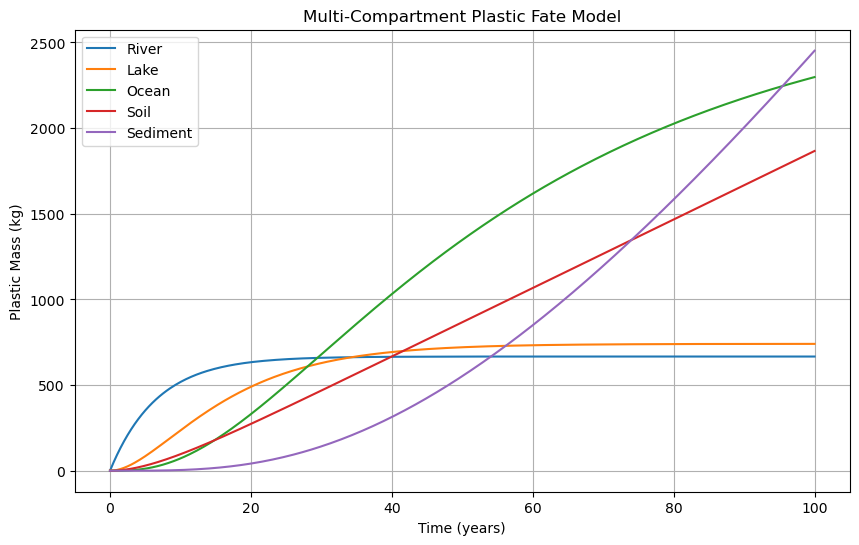

In [32]:

plt.figure(figsize=(10, 6))

plt.plot(
    solution.t,
    solution.y[0],
    label="River"
)

plt.plot(
    solution.t,
    solution.y[1],
    label="Lake"
)

plt.plot(
    solution.t,
    solution.y[2],
    label="Ocean"
)

plt.plot(
    solution.t,
    solution.y[3],
    label="Soil"
)

plt.plot(
    solution.t,
    solution.y[4],
    label="Sediment"
)

plt.xlabel("Time (years)")
plt.ylabel("Plastic Mass (kg)")

plt.title("Multi-Compartment Plastic Fate Model")

plt.legend()

plt.grid(True)

plt.show()


## Print the final compartment values:

In [33]:

print("\nFinal masses after 100 years:")

print(f"River: {solution.y[0][-1]:.2f} kg")
print(f"Lake : {solution.y[1][-1]:.2f} kg")
print(f"Ocean: {solution.y[2][-1]:.2f} kg")
print(f"Soil : {solution.y[3][-1]:.2f} kg")
print(f"Sediment : {solution.y[4][-1]:.2f} kg")


Final masses after 100 years:
River: 666.62 kg
Lake : 740.51 kg
Ocean: 2298.07 kg
Soil : 1866.68 kg
Sediment : 2451.99 kg


## Print the solution as a dataframe:

In [34]:
df = pd.DataFrame({
    "Year": solution.t,
    "River Mass (kg)": solution.y[0],
    "Lake Mass (kg)": solution.y[1],
    "Ocean Mass (kg)": solution.y[2],
    "Soil Mass (kg)": solution.y[3],
    "Sediment Mass (kg)": solution.y[4],
})

print(df.head())

       Year  River Mass (kg)  Lake Mass (kg)  Ocean Mass (kg)  Soil Mass (kg)  \
0  0.000000         0.000000        0.000000         0.000000        0.000000   
1  0.250627        24.597403        0.307842         0.002066        0.093051   
2  0.501253        48.287257        1.207037         0.016254        0.367611   
3  0.751880        71.103049        2.662319         0.053973        0.816984   
4  1.002506        93.077032        4.640026         0.125882        1.434719   

   Sediment Mass (kg)  
0            0.000000  
1            0.000003  
2            0.000041  
3            0.000205  
4            0.000639  


## Uncertainty Analysis

For the next iteration of this simplified model, I decided to investigate how uncertainty in environmental processes affects long-term plastic accumulation. Currently the model assumes exact transport and degradation rates, which is impossible to know. But, in reality - transport rates vary seasonally, degradation rates are uncertain, environmental measurements contain error, etc. 

Therefore there isn't a single answer, but we can establish a range of plausible outcomes.

By including uncertainty analysis, the research question for this model pivots to, *"How sensitive is long-term plastic accumulation to uncertainty in environmental transport and degradation rates?"*

To accomplish this, the model introduces Monte Carlo simulations to draw hypothetical values from a uniform distribution for some of the transport and degradation rates. These were limited to four parameters: 

1. `k_RL` : River --> Lake transport rate
2. `k_LO` : Lake --> Ocean transport rate
3. `k_OSed` : Ocean --> Sediment settling rate
4. `d_O` : Ocean degradation rate

These four parameters were chosen because they have a large influence on transport and accumulation in this particular model. 


In [35]:
n_simulations = 200

lake_final = []
ocean_final = []
sediment_final = []
lake_trajectories = []
ocean_trajectories = []
sediment_trajectories = []

for i in range(n_simulations):

    params_mc = params.copy()

    params_mc["k_RL"] = np.random.uniform(0.08, 0.12)

    params_mc["k_LO"] = np.random.uniform(0.06, 0.10)

    params_mc["k_OSed"] = np.random.uniform(0.01, 0.03)

    params_mc["d_O"] = np.random.uniform(0.0005, 0.002)

    solution_mc = solve_ivp(
        fate_model,
        (t_start, t_end),
        y0,
        args=(params_mc,),
        t_eval=t_eval
    )

    lake_final.append(
        solution_mc.y[1, -1]
    )

    ocean_final.append(
        solution_mc.y[2, -1]
    )

    sediment_final.append(
        solution_mc.y[4, -1]
    )

    lake_trajectories.append(
        solution_mc.y[1]
    )

    ocean_trajectories.append(
        solution_mc.y[2]
    )

    sediment_trajectories.append(
        solution_mc.y[4]
    )

lake_trajectories = np.array(
    lake_trajectories
)

ocean_trajectories = np.array(
    ocean_trajectories
)

sediment_trajectories = np.array(
    sediment_trajectories
)

### Lake Statistics

In [36]:
print("Lake Mass Statistics")

print(
    f"Mean: {np.mean(lake_final):.2f} kg"
)

print(
    f"Std: {np.std(lake_final):.2f} kg"
)

print(
    f"5th Percentile: {np.percentile(lake_final,5):.2f} kg"
)

print(
    f"95th Percentile: {np.percentile(lake_final,95):.2f} kg"
)

Lake Mass Statistics
Mean: 746.63 kg
Std: 99.53 kg
5th Percentile: 620.96 kg
95th Percentile: 919.39 kg


### Ocean Statistics

In [37]:
print("Ocean Mass Statistics")

print(
    f"Mean: {np.mean(ocean_final):.2f} kg"
)

print(
    f"Std: {np.std(ocean_final):.2f} kg"
)

print(
    f"5th Percentile: {np.percentile(ocean_final,5):.2f} kg"
)

print(
    f"95th Percentile: {np.percentile(ocean_final,95):.2f} kg"
)

Ocean Mass Statistics
Mean: 2318.25 kg
Std: 413.43 kg
5th Percentile: 1752.02 kg
95th Percentile: 2983.56 kg


### Sediment Statistics

In [38]:
print("Sediment Mass Statistics")

print(
    f"Mean: {np.mean(sediment_final):.2f} kg"
)

print(
    f"Std: {np.std(sediment_final):.2f} kg"
)

print(
    f"5th Percentile: {np.percentile(sediment_final,5):.2f} kg"
)

print(
    f"95th Percentile: {np.percentile(sediment_final,95):.2f} kg"
)

Sediment Mass Statistics
Mean: 2356.62 kg
Std: 471.42 kg
5th Percentile: 1538.69 kg
95th Percentile: 3046.63 kg


### Histograms for Lake and Ocean Monte Carlo Simulations

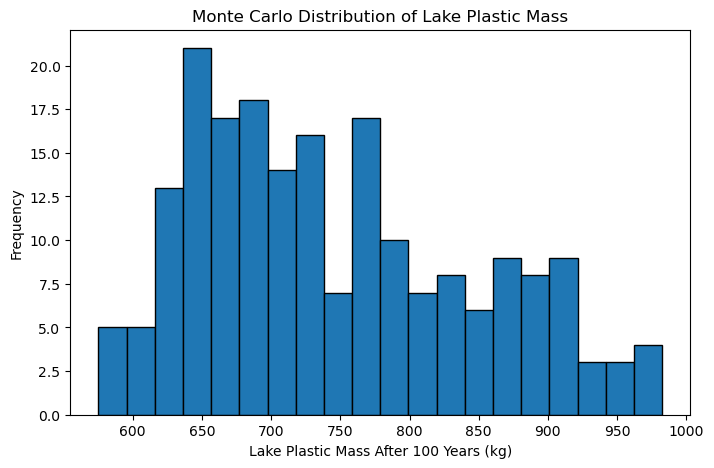

In [39]:
plt.figure(figsize=(8,5))

plt.hist(
    lake_final,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Lake Plastic Mass After 100 Years (kg)")
plt.ylabel("Frequency")

plt.title(
    "Monte Carlo Distribution of Lake Plastic Mass"
)

plt.show()

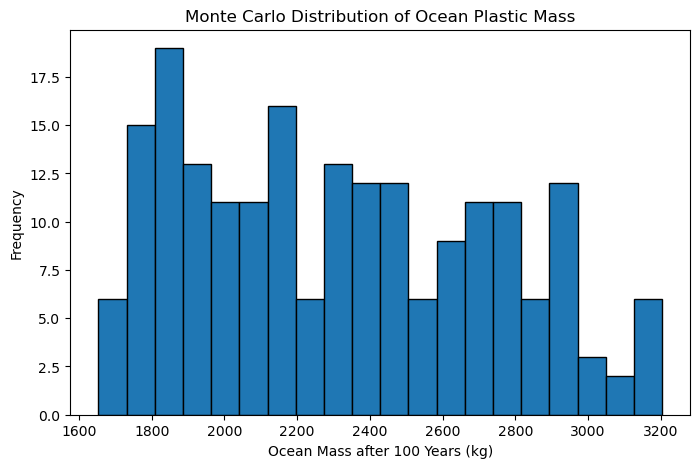

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    ocean_final,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Ocean Mass after 100 Years (kg)")
plt.ylabel("Frequency")

plt.title(
    "Monte Carlo Distribution of Ocean Plastic Mass"
)

plt.show()

### Boxplot Comparison

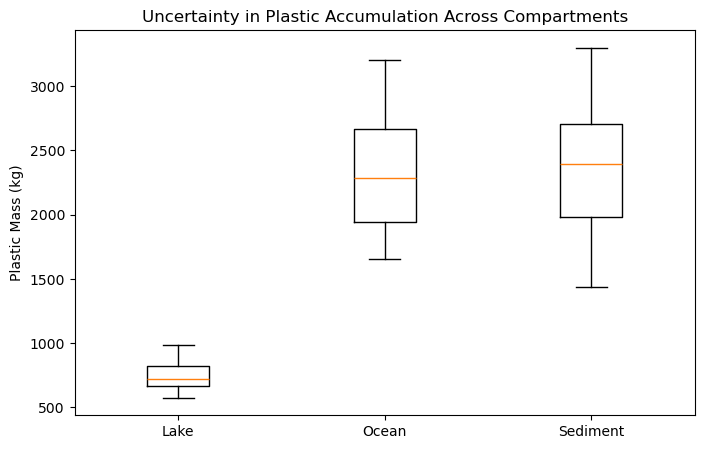

In [41]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        lake_final,
        ocean_final,
        sediment_final
    ],
    
    tick_labels=[
        "Lake",
        "Ocean",
        "Sediment"
    ]
)

plt.ylabel("Plastic Mass (kg)")

plt.title(
    "Uncertainty in Plastic Accumulation Across Compartments"
)

plt.show()

### Lake Plastic Accumulation Statistics

In [42]:
lake_lower = np.percentile(
    lake_trajectories,
    5,
    axis=0
)

lake_upper = np.percentile(
    lake_trajectories,
    95,
    axis=0
)

lake_median = np.percentile(
    lake_trajectories,
    50,
    axis=0
)


### Ocean Plastic Accumulation Statistics

In [43]:
ocean_lower = np.percentile(
    ocean_trajectories,
    5,
    axis=0
)

ocean_median = np.percentile(
    ocean_trajectories,
    50,
    axis=0
)

ocean_upper = np.percentile(
    ocean_trajectories,
    95,
    axis=0
)


### Sediment Plastic Accumulation Statistics

In [44]:
sediment_lower = np.percentile(
    sediment_trajectories,
    5,
    axis=0
)

sediment_median = np.percentile(
    sediment_trajectories,
    50,
    axis=0
)

sediment_upper = np.percentile(
    sediment_trajectories,
    95,
    axis=0
)

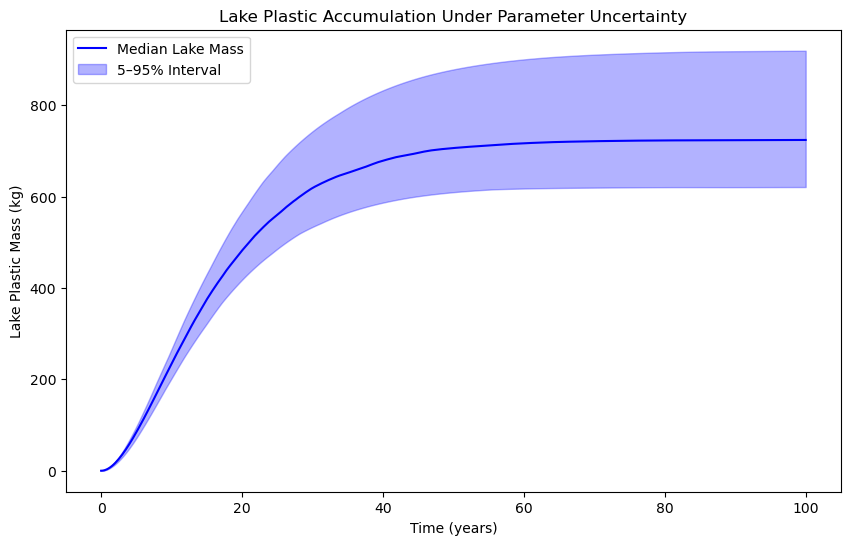

In [45]:
plt.figure(figsize=(10,6))

plt.plot(
    t_eval,
    lake_median,
    color="blue",
    label="Median Lake Mass"
)

plt.fill_between(
    t_eval,
    lake_lower,
    lake_upper,
    alpha=0.3,
    color="blue",
    label="5–95% Interval"
)

plt.xlabel("Time (years)")
plt.ylabel("Lake Plastic Mass (kg)")

plt.title(
    "Lake Plastic Accumulation Under Parameter Uncertainty"
)

plt.legend()

plt.show()

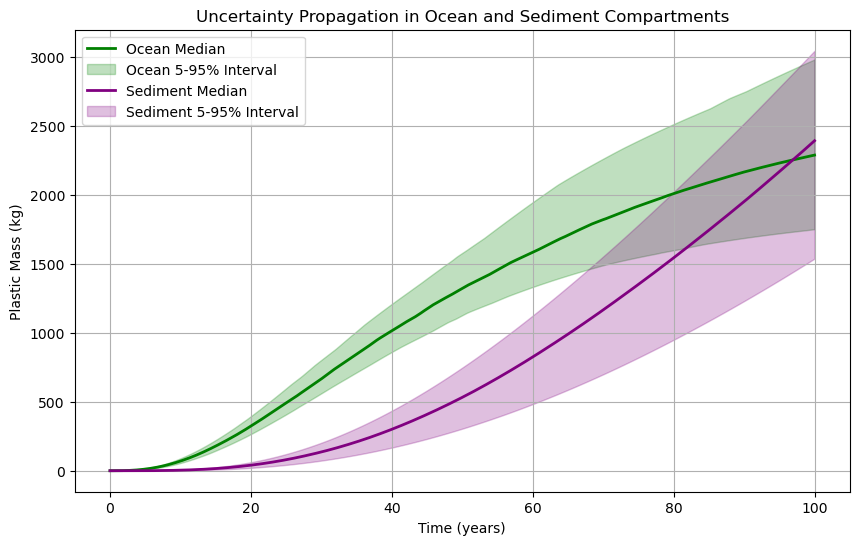

In [46]:
plt.figure(figsize=(10,6))

# Ocean
plt.plot(
    t_eval,
    ocean_median,
    color="green",
    linewidth=2,
    label="Ocean Median"
)

plt.fill_between(
    t_eval,
    ocean_lower,
    ocean_upper,
    color="green",
    alpha=0.25,
    label="Ocean 5-95% Interval"
)

# Sediment
plt.plot(
    t_eval,
    sediment_median,
    color="purple",
    linewidth=2,
    label="Sediment Median"
)

plt.fill_between(
    t_eval,
    sediment_lower,
    sediment_upper,
    color="purple",
    alpha=0.25,
    label="Sediment 5-95% Interval"
)

plt.xlabel("Time (years)")
plt.ylabel("Plastic Mass (kg)")
plt.title(
    "Uncertainty Propagation in Ocean and Sediment Compartments"
)

plt.legend()
plt.grid(True)

plt.show()